In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

To answer this question, we will first check how many countries are both in top 10 for casualties and the Guardian articles, then, we will find their pearson correlation coefficient to measures strength of linear relationship between these two variable in each region, and see how does this correlation changed over time from 2015 to 2024. The reason why we choose Pearson correlation is that we are testing linear relationsip between these variable and both of them are continous and quantitativ measures. In addition to that, as we also intend to compare the responsiveness in each region, Pearson correlation is a good idea as it also show us the strength of the relationship

Step 1: Preparing data for our analysis


In [12]:
monthly = pd.read_csv('..\data\master_monthly.csv')
master  = pd.read_csv('..\data\master.csv')
wb      = pd.read_csv('..\data\worldbank_income_clean.csv')
 
wb_region = wb[['country', 'region_group']].drop_duplicates()
 
# Join monthly
monthly = monthly.drop(columns='region_group')
monthly = monthly.merge(wb_region, on='country', how='inner')
 
# Join master
master = master.drop(columns='region_group')
master = master.merge(wb_region, on='country', how='inner')
 
df = monthly[monthly['monthly_fatalities'].notna()].copy()
 
yearly_agg = df.groupby(['year', 'region_group']).agg(
    total_articles   = ('article_count',     'sum'),
    total_fatalities = ('monthly_fatalities', 'sum')
).reset_index()
 

Step 2: Prepare graph plotting function for analysis

In [13]:
def build_yearly_scatter(yearly, title):
    """
    Side-by-side scatter: Global South | Global North.
    One point per year, with Pearson r and OLS trend line.
    Prints stats when called.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
 
    print(f"\n{'='*60}")
    print(f"PEARSON – {title}")
    print(f"{'='*60}")
 
    for ax, (region, color) in zip([ax1, ax2], [
        ('Global South', '#E07A5F'),
        ('Global North', '#3D405B')
    ]):
        sub = yearly[yearly['region_group'] == region]
        if len(sub) < 3:
            continue
 
        r_val, p_val = pearsonr(sub['total_fatalities'], sub['total_articles'])
        print(f"  {region}:  r = {r_val:.4f}, p = {p_val:.4e}, n = {len(sub)}")
 
        # Scatter with year labels
        ax.scatter(sub['total_fatalities'], sub['total_articles'],
                   color=color, s=80, zorder=3)
        for _, row in sub.iterrows():
            ax.annotate(str(int(row['year'])),
                        (row['total_fatalities'], row['total_articles']),
                        textcoords='offset points', xytext=(0, 8),
                        fontsize=8, ha='center')
 
        # OLS trend line
        z = np.polyfit(sub['total_fatalities'], sub['total_articles'], 1)
        x_line = np.linspace(sub['total_fatalities'].min(),
                             sub['total_fatalities'].max(), 100)
        ax.plot(x_line, np.polyval(z, x_line), '--', color=color, linewidth=2)
 
        # Pearson annotation
        ax.text(0.95, 0.95, f"r = {r_val:.3f}, p = {p_val:.2e}",
                transform=ax.transAxes, fontsize=11, ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor=color, alpha=0.8))
 
        ax.set_title(region, fontsize=12, fontweight='bold')
        ax.set_xlabel('Yearly Casualties', fontsize=10)
        ax.grid(True, alpha=0.3)
        y_min, y_max = ax.get_ylim()
        y_pad = (y_max - y_min) * 0.08
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
 
    ax1.set_ylabel('Yearly Articles', fontsize=10)
 
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
 
 
def build_scatter(master_data, region, color, title):
    """
    Scatter plot of casualties vs articles for one region (country-level).
    Prints Pearson r when called.
    """
    sub = master_data[
        (master_data['region_group'] == region) &
        (master_data['total_fatalities'].notna()) &
        (master_data['total_fatalities'] > 0)
    ].copy()
 
    r_val, p_val = pearsonr(sub['total_fatalities'], sub['total_articles'])
    print(f"\n{region} country-level Pearson: r = {r_val:.4f}, p = {p_val:.4e}, n = {len(sub)}")
 
    fig, ax = plt.subplots(figsize=(10, 6))
 
    ax.scatter(sub['total_fatalities'], sub['total_articles'],
               color=color, s=50, alpha=0.7, zorder=3)
 
    for _, row in sub.iterrows():
        ax.annotate(row['country'],
                    (row['total_fatalities'], row['total_articles']),
                    textcoords='offset points', xytext=(0, 6),
                    fontsize=7, ha='center', color='grey')
 
    # OLS trend line
    z = np.polyfit(sub['total_fatalities'], sub['total_articles'], 1)
    x_line = np.linspace(sub['total_fatalities'].min(), sub['total_fatalities'].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), '--', color=color, linewidth=2)
 
    ax.text(0.95, 0.95, f"r = {r_val:.3f}, p = {p_val:.2e}, n = {len(sub)}",
            transform=ax.transAxes, fontsize=12, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor=color, alpha=0.8))
 
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Total Casualties', fontsize=11)
    ax.set_ylabel('Total Articles', fontsize=11)
    ax.grid(True, alpha=0.3)
 
    plt.tight_layout()
    plt.show()
 
 
def build_top10_bars(master_data, region, color_art, color_cas, title):
    """
    Two horizontal bar charts stacked vertically:
      Top: top 10 by article count
      Bottom: top 10 by casualty count
    """
    sub = master_data[
        (master_data['region_group'] == region) &
        (master_data['total_fatalities'].notna()) &
        (master_data['total_fatalities'] > 0)
    ]
 
    top_articles = sub.nlargest(10, 'total_articles').sort_values('total_articles')
    top_casualties = sub.nlargest(10, 'total_fatalities').sort_values('total_fatalities')
 
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 10))
 
    # Top: articles
    ax1.barh(top_articles['country'], top_articles['total_articles'], color=color_art)
    for i, (val, country) in enumerate(zip(top_articles['total_articles'], top_articles['country'])):
        ax1.text(val + top_articles['total_articles'].max() * 0.02, i, f'{val:,}',
                 va='center', fontsize=9)
    ax1.set_xlabel('Total Articles', fontsize=11)
    ax1.set_title(f'{region}: Top 10 by Article Count', fontsize=12, fontweight='bold')
    ax1.set_xlim(0, top_articles['total_articles'].max() * 1.25)
    ax1.grid(True, axis='x', alpha=0.3)
 
    # Bottom: casualties
    ax2.barh(top_casualties['country'], top_casualties['total_fatalities'], color=color_cas)
    for i, (val, country) in enumerate(zip(top_casualties['total_fatalities'], top_casualties['country'])):
        ax2.text(val + top_casualties['total_fatalities'].max() * 0.02, i, f'{val:,.0f}',
                 va='center', fontsize=9)
    ax2.set_xlabel('Total Casualties', fontsize=11)
    ax2.set_title(f'{region}: Top 10 by Casualty Count', fontsize=12, fontweight='bold')
    ax2.set_xlim(0, top_casualties['total_fatalities'].max() * 1.25)
    ax2.grid(True, axis='x', alpha=0.3)
 
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
 
 
def build_pearson_by_year(monthly_data):
    """
    Line chart of Pearson r by year for both regions.
    Prints correlation stats when called.
    """
    df = monthly_data[monthly_data['monthly_fatalities'].notna()].copy()
 
    yearly = df.groupby(['country', 'year', 'region_group']).agg(
        total_articles   = ('article_count',     'sum'),
        total_fatalities = ('monthly_fatalities', 'sum')
    ).reset_index()
 
    results = []
    for region in ['Global South', 'Global North']:
        for year in sorted(yearly['year'].unique()):
            sub = yearly[(yearly['region_group'] == region) & (yearly['year'] == year)]
            if len(sub) > 2:
                r_val, p_val = pearsonr(sub['total_fatalities'], sub['total_articles'])
                countries = sorted(sub['country'].tolist())
                results.append({
                    'year': year,
                    'region_group': region,
                    'r': r_val,
                    'p': p_val,
                    'n': len(sub),
                    'significant': p_val < 0.05,
                    'countries': countries
                })
 
    results_df = pd.DataFrame(results)
 
    print(f"\n{'='*60}")
    print("PEARSON r BY YEAR")
    print(f"{'='*60}")
    for _, row in results_df.iterrows():
        sig = '***' if row['p'] < 0.001 else '**' if row['p'] < 0.01 else '*' if row['p'] < 0.05 else ''
        print(f"  {row['region_group']:15s} {row['year']}  r={row['r']:.3f}  p={row['p']:.4e}  n={row['n']:>3} {sig}")
 
    gs = results_df[results_df['region_group'] == 'Global South']
    gn = results_df[results_df['region_group'] == 'Global North']
 
    fig, ax = plt.subplots(figsize=(10, 5.5))
 
    for subset, name, color, y_offset in [
        (gs, 'Global South', '#E07A5F', 12),
        (gn, 'Global North', '#3D405B', -16)
    ]:
        sig_mask = subset['significant']
 
        # Line
        ax.plot(subset['year'], subset['r'], '-', color=color, linewidth=2, label=name)
 
        # Filled markers (significant)
        if sig_mask.any():
            ax.scatter(subset.loc[sig_mask, 'year'], subset.loc[sig_mask, 'r'],
                       color=color, s=80, zorder=4, marker='o')
 
        # Open markers (not significant)
        if (~sig_mask).any():
            ax.scatter(subset.loc[~sig_mask, 'year'], subset.loc[~sig_mask, 'r'],
                       facecolors='white', edgecolors=color, s=80, zorder=4,
                       marker='o', linewidths=1.5)
 
        # n labels
        for _, row in subset.iterrows():
            ax.annotate(f"n={row['n']}", (row['year'], row['r']),
                        textcoords='offset points', xytext=(0, y_offset),
                        fontsize=8, ha='center', color=color)
 
    ax.axhline(y=0, linestyle=':', color='grey', alpha=0.5)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Pearson r', fontsize=11)
    ax.set_title('Pearson Correlation (Casualties vs Articles) by Year and Region',
                 fontsize=13, fontweight='bold')
    ax.set_ylim(-0.3, 1.0)
    ax.set_xticks(range(2015, 2025))
    ax.legend(loc='lower left', framealpha=0.8)
    ax.grid(True, alpha=0.3)
 
    fig.text(0.5, -0.02,
             '● filled = significant (p < 0.05)   ○ open = not significant',
             ha='center', fontsize=10, color='grey')
 
    plt.tight_layout()
    plt.show()

Step 3: We will now plot graph for our analysis

Graph 1


PEARSON – Yearly: The Guardian articles vs ACLED casualties by region
  Global South:  r = 0.3910, p = 2.6384e-01, n = 10
  Global North:  r = 0.7856, p = 1.2096e-02, n = 9


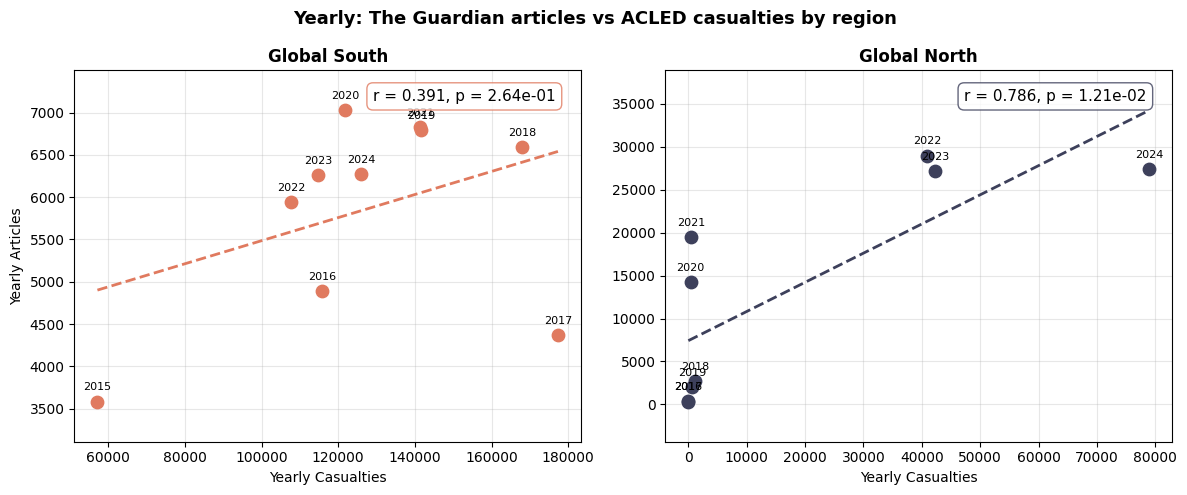

In [14]:
build_yearly_scatter(
    yearly_agg,
    'Yearly: The Guardian articles vs ACLED casualties by region'
)

The scatter graph show that these two variables have stronger correlation in Global North than in Global South, with the pearson correlation of 0.7856 compare to 0.3910. Also, consider the p-value of Global South which is 0.26 compared to 0.012 of Global North, we can conclude that it was statistically significant that casualties have positive correlation to number of articles in Global North than in Global South from 2015 to 2024



Graph 2

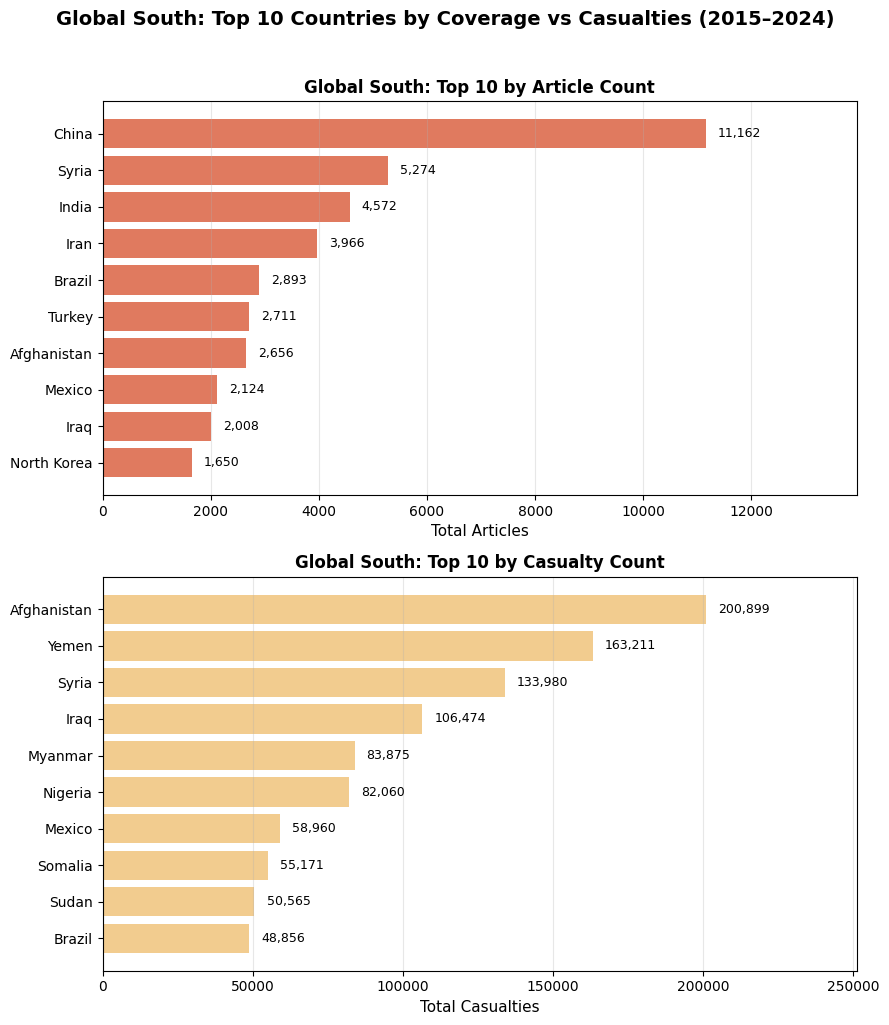


Global South country-level Pearson: r = 0.3302, p = 3.7789e-04, n = 112


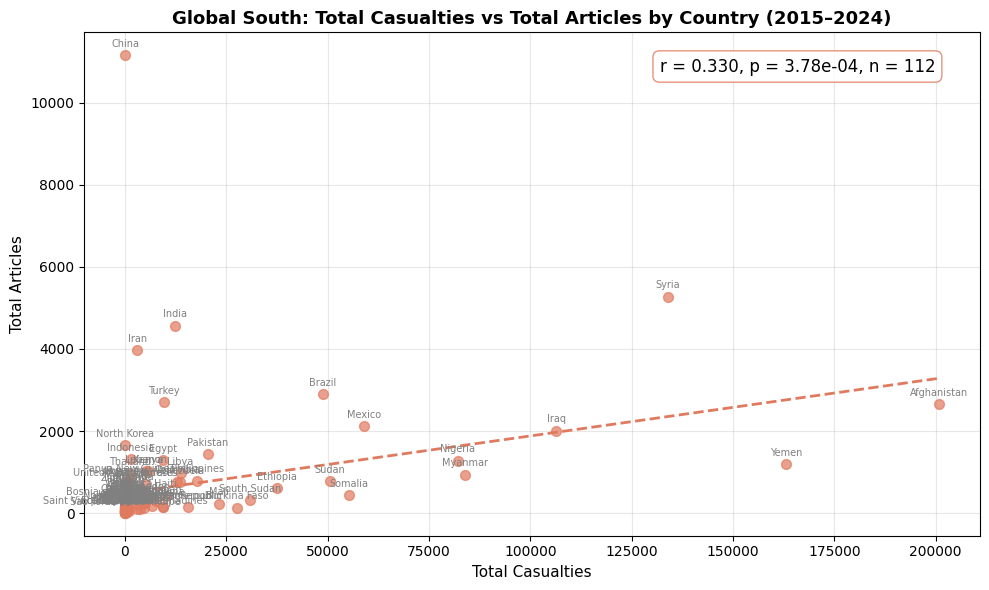

In [15]:
build_top10_bars(
    master, 'Global South', '#E07A5F', '#F2CC8F',
    'Global South: Top 10 Countries by Coverage vs Casualties (2015–2024)'
)
 
build_scatter(
    master, 'Global South', '#E07A5F',
    'Global South: Total Casualties vs Total Articles by Country (2015–2024)'
)

As we already found out there was correlation between casualties and articles in Global South, we first find out whether top 10 countries with highest casualties were also top 10 countries with highest number of articles. The bar chart show that 5/10 countries appeared in both list

To find out whether the correlation still hold, we will also plot scatter graph between casualties and articles by country.

The above plot show there was statistically significant medium positive correlation of 0.330, indicates the Guardian actually did respond to casualties spike in this region

Graph 3

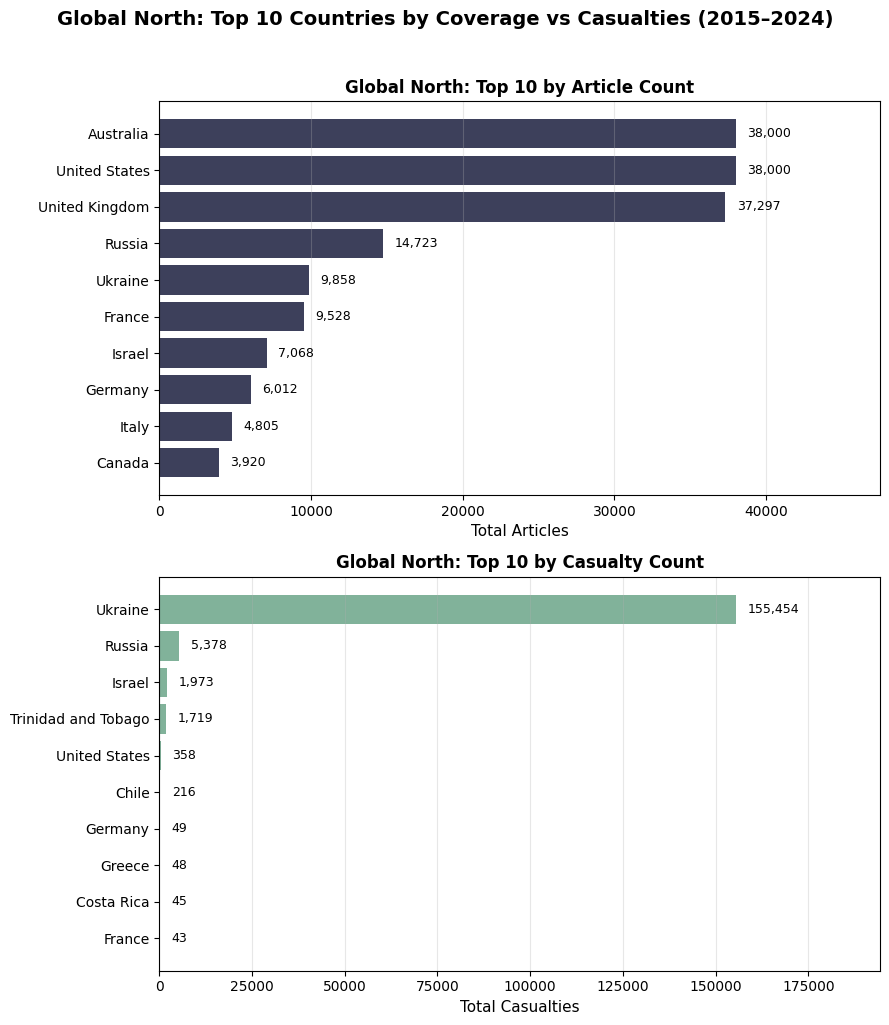


Global North country-level Pearson: r = 0.0946, p = 5.4116e-01, n = 44


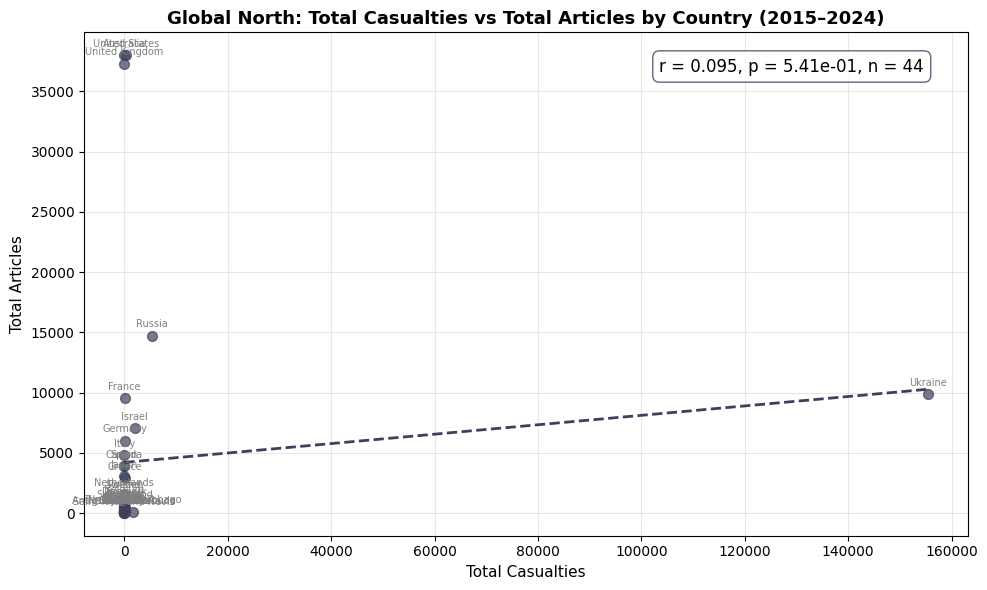

In [16]:
build_top10_bars(
    master, 'Global North', '#3D405B', '#81B29A',
    'Global North: Top 10 Countries by Coverage vs Casualties (2015–2024)'
)
 
build_scatter(
    master, 'Global North', '#3D405B',
    'Global North: Total Casualties vs Total Articles by Country (2015–2024)'
)

When we do the same thing for the Global North, even though 6/10 countries appeared in both list, the number wasn't as coherent like in Global South analysis. 

Surpringsingly, this graph show different result compare to our first graph. This scatter graph show that the correlation between casualties and articles in Global North was statistically insignificant and very weak. Hence, this show that the correlation we found in first graph was just coincident and Global North related articles might be driven by other reason such as geopolitical or reason related to the demographic of reader rather than in respond to casualty spike

To find out how responsive of the Guardian toward casualties changed overtime, we plot line graph show how pearson correlation changed by year. Noted that at some year, some countries have no casualties data due to ACLED limitation, so the number of countries included in each region each year is different

Graph 4


PEARSON r BY YEAR
  Global South    2015  r=0.462  p=5.5763e-04  n= 52 ***
  Global South    2016  r=0.529  p=8.3539e-06  n= 63 ***
  Global South    2017  r=0.619  p=3.0374e-08  n= 66 ***
  Global South    2018  r=0.321  p=8.7527e-04  n=104 ***
  Global South    2019  r=0.198  p=4.6067e-02  n=102 *
  Global South    2020  r=0.099  p=3.1274e-01  n=105 
  Global South    2021  r=0.529  p=5.2358e-10  n=120 ***
  Global South    2022  r=0.141  p=1.4886e-01  n=107 
  Global South    2023  r=0.149  p=1.1124e-01  n=115 
  Global South    2024  r=0.201  p=3.0641e-02  n=116 *
  Global North    2018  r=0.098  p=6.4824e-01  n= 24 
  Global North    2019  r=0.278  p=2.0961e-01  n= 22 
  Global North    2020  r=0.369  p=5.1318e-03  n= 56 **
  Global North    2021  r=0.239  p=5.1154e-02  n= 67 
  Global North    2022  r=0.415  p=8.8088e-04  n= 61 ***
  Global North    2023  r=0.222  p=8.8576e-02  n= 60 
  Global North    2024  r=0.133  p=3.1635e-01  n= 59 


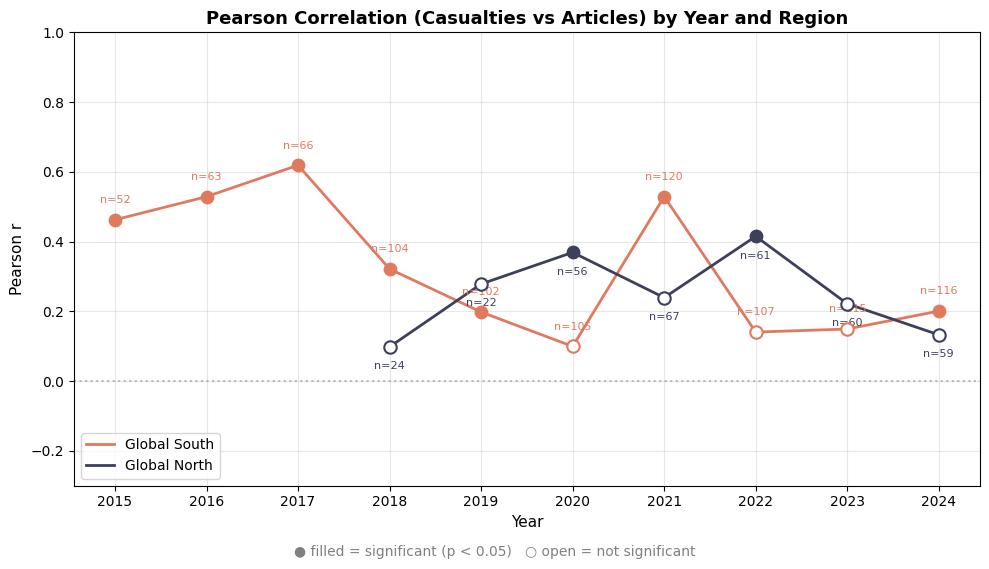

In [17]:
build_pearson_by_year(monthly)



We can see that the Guardian is less responsive toward casualties spike in Global South over the year, with only exception of a spike in 2021. Meanwhile, in Global North, the Guardian responsiveness toward casualties spiked relatively unchanged, except in 2020 and in 2022, which was the start of the Russia - Ukraine war



However, as we saw that there was some outliers in the data such as China in Global South or US, UK and Australia in Global North with high number of articles and low number of casualties, as these country have significant geopolitical influence or where most of the Guardian readers based in. In addition to that, these outliers also violated the assumption of the Pearson correlation, which may affected to it's behaviour.




PEARSON r BY YEAR
  Global South    2015  r=0.462  p=5.5763e-04  n= 52 ***
  Global South    2016  r=0.529  p=8.3539e-06  n= 63 ***
  Global South    2017  r=0.619  p=3.0374e-08  n= 66 ***
  Global South    2018  r=0.448  p=2.0861e-06  n=103 ***
  Global South    2019  r=0.343  p=4.3742e-04  n=101 ***
  Global South    2020  r=0.304  p=1.7262e-03  n=104 **
  Global South    2021  r=0.777  p=2.7958e-25  n=119 ***
  Global South    2022  r=0.311  p=1.1730e-03  n=106 **
  Global South    2023  r=0.335  p=2.7475e-04  n=114 ***
  Global South    2024  r=0.284  p=2.0609e-03  n=115 **
  Global North    2018  r=0.098  p=6.4824e-01  n= 24 
  Global North    2019  r=0.278  p=2.0961e-01  n= 22 
  Global North    2020  r=0.124  p=3.7231e-01  n= 54 
  Global North    2021  r=0.097  p=4.4407e-01  n= 64 
  Global North    2022  r=0.708  p=5.0672e-10  n= 58 ***
  Global North    2023  r=0.642  p=7.3698e-08  n= 57 ***
  Global North    2024  r=0.446  p=5.6289e-04  n= 56 ***


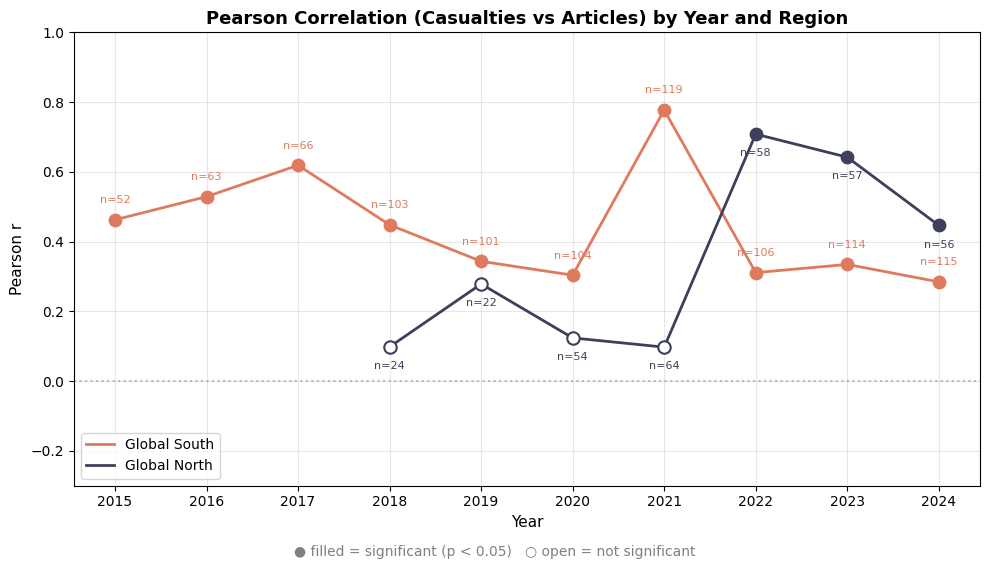

In [18]:
EXCLUDE_GS = ['China']
EXCLUDE_GN = ['United Kingdom', 'United States', 'Australia']
 
monthly_no_outliers = monthly[~(
    ((monthly['region_group'] == 'Global South') & (monthly['country'].isin(EXCLUDE_GS))) |
    ((monthly['region_group'] == 'Global North') & (monthly['country'].isin(EXCLUDE_GN)))
)]
 
build_pearson_by_year(monthly_no_outliers)

As we can see, when we exclude these outliers, the result actually became very different. Now, all the result for Global South are statistically significant and from 2022-2024, the pearson correlation for Global North region were statistically significant. In addition to that, the pearson correlation also increased compared to when we included those outlier, suggest, the Guardian were responsive to casualties when we exclude country where a lots of the Guardian reader lived or country with significant geopolitical influence like China

The graph did show a different result, as all of the pearson correlation between these variables in Global South were stronger and statistically significant. Meanwhile, in Global North, the correlation also became statistically significant from 2022 to 2024 and stronger. 